# Phân Tích Hành Vi Mua Sắm Của Khách Hàng
---
## Bối cảnh bài toán

**Vấn đề kinh doanh:** Một doanh nghiệp thương mại điện tử chuyên bán thời trang & phụ kiện đang đối mặt với bài toán: *Làm sao để hiểu rõ khách hàng, từ đó tối ưu chiến lược tiếp thị, tăng doanh thu và giảm tỷ lệ rời bỏ?*

**Câu hỏi cần trả lời:**
1. Khách hàng của chúng ta là ai? (Nhân khẩu học, hành vi mua sắm)
2. Có thể chia khách hàng thành các nhóm rõ ràng không? (Phân cụm)
3. Làm sao dự đoán nhóm khách hàng mới? (Prediction)
4. Gợi ý sản phẩm phù hợp cho từng khách hàng? (Recommendation)

**Dữ liệu:** 3.900 bản ghi giao dịch mua sắm với 18 thuộc tính bao gồm nhân khẩu học, sản phẩm, thanh toán và vận chuyển.

**Cấu trúc phân tích:**
| Section | Nội dung | Mục đích kinh doanh |
|---------|----------|---------------------|
| 1 | EDA – Khám phá dữ liệu | Hiểu bức tranh toàn cảnh khách hàng |
| 2 | Phân cụm K-Means | Phân nhóm khách hàng để cá nhân hóa |
| 3 | Dự đoán cụm khách hàng | Tự động phân loại khách hàng mới |
| 4 | Hệ thống gợi ý sản phẩm | Tăng tỷ lệ chuyển đổi & doanh thu |

# 1. Phân Tích Khám Phá Dữ Liệu (EDA)

## 1.0 Import thư viện & Load dữ liệu

In [61]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, silhouette_score
)
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:,.1f}".format

# Bảng màu thống nhất
COLORS = ["#89CFF0", "#FF69B4", "#FFD700", "#7B68EE", "#FF4500",
          "#9370DB", "#32CD32", "#8A2BE2", "#FF6347", "#20B2AA"]
PALETTE = ["#ADA2FF", "#C0DEFF", "#FCDDB0", "#FF9F9F", "#EDD2F3"]

In [62]:
# Load dữ liệu
df = pd.read_csv('data/shopping_trends.csv')
print(f"Dataset: {df.shape[0]} dòng × {df.shape[1]} cột")
df.head()

Dataset: 3900 dòng × 18 cột


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,58,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Monthly
1,2,19,Male,Sweater,Clothing,79,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Monthly
2,3,45,Male,Blouse,Clothing,64,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
3,4,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Standard,Yes,Yes,14,Venmo,Weekly
4,5,27,Male,Shorts,Clothing,49,Louisiana,L,Charcoal,Winter,3.2,Yes,Free Shipping,Yes,Yes,19,Credit Card,Weekly


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

### Mô tả các cột dữ liệu

| Nhóm | Cột | Ý nghĩa |
|------|-----|---------|
| **Nhân khẩu học** | Customer ID, Age, Gender, Location | Thông tin cá nhân khách hàng |
| **Sản phẩm** | Item Purchased, Category, Size, Color | Chi tiết sản phẩm đã mua |
| **Giao dịch** | Purchase Amount (USD), Season, Review Rating | Giá trị, mùa, đánh giá |
| **Hành vi** | Previous Purchases, Frequency of Purchases, Subscription Status | Lịch sử & thói quen |
| **Thanh toán & Vận chuyển** | Payment Method, Shipping Type, Discount Applied, Promo Code Used | Phương thức & ưu đãi |

## 1.1 Làm sạch dữ liệu

In [64]:
# Đổi tên cột cho gọn
df.columns = df.columns.str.replace(" ", "_")
df.rename(columns={"Purchase_Amount_(USD)": "Price_in_USD"}, inplace=True)

# Kiểm tra dữ liệu trùng & null
print(f"Giá trị trùng lặp: {df.duplicated().sum()}")
print(f"Giá trị null: {df.isnull().sum().sum()}")
print(f"\nSố dòng: {len(df)}")

Giá trị trùng lặp: 0
Giá trị null: 0

Số dòng: 3900


In [65]:
df.describe()

,Customer_ID,Age,Price_in_USD,Review_Rating,Previous_Purchases
count,"3,900.0","3,900.0","3,900.0","3,900.0","3,900.0"
mean,"1,950.5",44.1,56.9,3.8,25.4
std,"1,126.0",15.2,21.6,0.7,14.4
min,1.0,18.0,20.0,2.5,1.0
25%,975.8,31.0,38.0,3.1,13.0
50%,"1,950.5",44.0,55.0,3.8,25.0
75%,"2,925.2",57.0,76.0,4.4,38.0
max,"3,900.0",70.0,100.0,5.0,50.0


**Nhận xét:**
- Dữ liệu **sạch**: không có giá trị trùng lặp hay null → sẵn sàng phân tích.
- Tuổi khách hàng: 18–70, trung bình 44 tuổi → nhóm trung niên là chủ lực.
- Chi tiêu/đơn hàng: $20–$100, trung bình $60 → phân khúc bình dân đến trung cấp.
- Đánh giá: trung bình 3.7/5 → tốt nhưng chưa xuất sắc.

## 1.2 Phân tích doanh thu

### Doanh thu & số đơn hàng theo danh mục sản phẩm

In [66]:
# Doanh thu & số lượng đơn hàng theo danh mục
cat_analysis = df.groupby("Category").agg(
    Revenue=("Price_in_USD", "sum"),
    Orders=("Customer_ID", "count"),
    Avg_Order_Value=("Price_in_USD", "mean")
).sort_values("Revenue", ascending=False)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=["Doanh thu theo danh mục (USD)", "Giá trị đơn hàng trung bình (USD)"]
)

fig.add_trace(go.Bar(
    x=cat_analysis.index, y=cat_analysis['Revenue'],
    marker_color=PALETTE[:4],
    text=cat_analysis['Revenue'].apply(lambda x: f"${x:,.0f}"),
    textposition='auto',
    hovertemplate="<b>%{x}</b><br>Doanh thu: $%{y:,.0f}<extra></extra>"
), row=1, col=1)

fig.add_trace(go.Bar(
    x=cat_analysis.index, y=cat_analysis['Avg_Order_Value'],
    marker_color=PALETTE[:4],
    text=cat_analysis['Avg_Order_Value'].apply(lambda x: f"${x:.0f}"),
    textposition='auto',
    hovertemplate="<b>%{x}</b><br>AOV: $%{y:.0f}<extra></extra>"
), row=1, col=2)

fig.update_layout(showlegend=False, title_font_size=22, height=450)
fig.show()

print(cat_analysis.to_string())

             Revenue  Orders  Avg_Order_Value
Category                                     
Clothing       87403    1302             67.1
Accessories    51377    1098             46.8
Outerwear      46059     792             58.2
Footwear       37184     708             52.5


**Nhận xét:** Clothing dẫn đầu doanh thu nhờ số đơn hàng áp đảo (1.302 đơn), nhưng giá trị trung bình/đơn (AOV) giữa 4 danh mục gần tương đương (~$57-62). Điểm khác biệt nằm ở **số lượng**, không phải giá trị đơn.

**Nguyên nhân:** Clothing là nhu cầu thiết yếu với tần suất thay thế cao. Footwear & Outerwear có chu kỳ mua dài hơn nên số đơn ít dù AOV không thấp.

**Hành động:**
- **Clothing (chiếm ~35% doanh thu)**: Đây là nguồn doanh thu ổn định – duy trì chất lượng, tốc độ bổ sung mẫu mới
- **Footwear (ít đơn nhất)**: A/B test giảm giá 10-15% xem có tăng đáng kể số đơn không – nếu AOV giảm nhưng volume tăng gấp đôi thì vẫn lời
- **Outerwear**: Tập trung bán mạnh vào Q4 (mùa đông) thay vì dàn trải cả năm

### Doanh thu theo mùa – Khi nào bán gì?

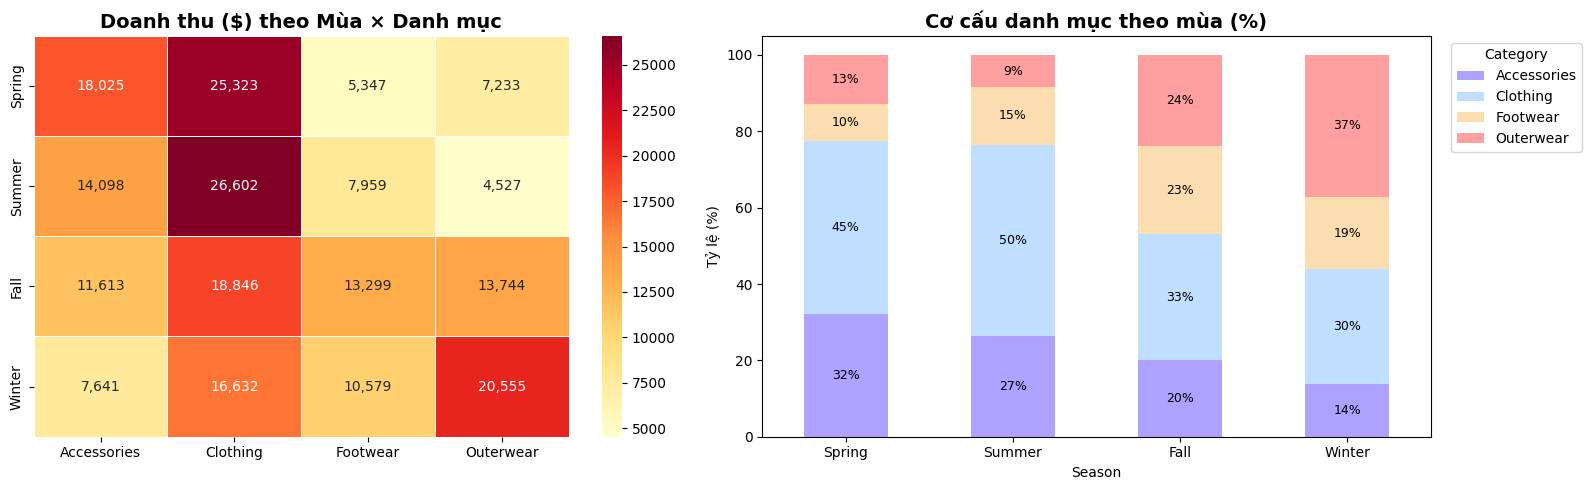

In [67]:
# Doanh thu theo mùa x danh mục (heatmap)
season_cat = df.pivot_table(
    index="Season", columns="Category",
    values="Price_in_USD", aggfunc="sum"
).reindex(["Spring", "Summer", "Fall", "Winter"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap doanh thu
sns.heatmap(season_cat, annot=True, fmt=",.0f", cmap="YlOrRd",
            linewidths=0.5, ax=axes[0])
axes[0].set_title("Doanh thu ($) theo Mùa × Danh mục", fontsize=14, weight="bold")
axes[0].set_ylabel(""); axes[0].set_xlabel("")

# Stacked bar % theo mùa
season_cat_pct = season_cat.div(season_cat.sum(axis=1), axis=0) * 100
season_cat_pct.plot(kind='bar', stacked=True, color=PALETTE[:4], ax=axes[1], rot=0)
axes[1].set_title("Cơ cấu danh mục theo mùa (%)", fontsize=14, weight="bold")
axes[1].set_ylabel("Tỷ lệ (%)")
axes[1].legend(title="Category", bbox_to_anchor=(1.02, 1), loc='upper left')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.0f%%', label_type='center', fontsize=9)

plt.tight_layout()
plt.show()

**Nhận xét:**
- **Mùa đông**: Outerwear chiếm tỷ trọng lớn nhất (~37%), trong khi mùa hè Outerwear gần như biến mất (~8%)
- **Clothing** luôn dẫn đầu ngoại trừ mùa đông
- **Accessories** tương đối ổn định quanh năm – ít bị ảnh hưởng theo mùa

**Nguyên nhân:** Hành vi mua sắm phản ánh nhu cầu thực tế theo thời tiết. Accessories ổn định vì đây là sản phẩm "bổ trợ", không phụ thuộc thời tiết.

**Hành động:**
- **Quản lý tồn kho theo mùa**: Tăng sản xuất Outerwear từ tháng 9, giảm từ tháng 3. Clothing ngược lại.
- **Cross-season deals**: "Mua áo khoác mùa hè – giảm 30%" → xả hàng tồn + tạo nhu cầu sớm
- **Accessories là sản phẩm cross-sell quanh năm** → luôn đề xuất kèm theo đơn hàng chính

## 1.3 Phân tích chân dung khách hàng giá trị

### Chi tiêu theo nhóm tuổi & giới tính – Ai đáng đầu tư nhất?

In [68]:
# Tạo nhóm tuổi
bins = [18, 30, 40, 50, 70]
labels_age = ['18-29', '30-39', '40-49', '50+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels_age, right=False)

# Phân tích chi tiêu theo tuổi x giới tính
age_gender = df.groupby(['AgeGroup', 'Gender'], observed=True).agg(
    Total_Revenue=('Price_in_USD', 'sum'),
    Num_Orders=('Customer_ID', 'count'),
    Avg_Spend=('Price_in_USD', 'mean')
).reset_index()

fig = px.bar(
    age_gender, x='AgeGroup', y='Total_Revenue', color='Gender',
    barmode='group', text_auto='$,.0f',
    color_discrete_map={'Male': '#ADA2FF', 'Female': '#FF9F9F'},
    labels={'AgeGroup': 'Nhóm tuổi', 'Total_Revenue': 'Doanh thu (USD)', 'Gender': 'Giới tính'},
    title='Doanh thu theo nhóm tuổi & giới tính'
)
fig.update_layout(title_font_size=22, height=450)
fig.update_traces(textfont_size=12)
fig.show()

# In tỷ lệ
total = df['Price_in_USD'].sum()
male_rev = df[df['Gender']=='Male']['Price_in_USD'].sum()
print(f"Nam đóng góp: ${male_rev:,.0f} ({male_rev/total*100:.1f}%)")
print(f"Nữ đóng góp: ${total-male_rev:,.0f} ({(total-male_rev)/total*100:.1f}%)")

Nam đóng góp: $151,204 (68.1%)
Nữ đóng góp: $70,819 (31.9%)


**Nhận xét:** Nam giới chiếm ~68% doanh thu ở mọi nhóm tuổi, tỷ lệ nam/nữ đồng đều qua các nhóm tuổi. Nhóm 50+ có tổng doanh thu cao nhất nhờ lượng khách đông (phạm vi tuổi rộng hơn: 50-70).

**Nguyên nhân:** Tỷ lệ khách hàng nam/nữ trong dataset là 68/32, doanh thu phản ánh đúng tỷ lệ này. Chi tiêu trung bình/đơn giữa nam và nữ tương đương → khác biệt nằm ở **số lượng khách**, không phải **khả năng chi trả**.

**Hành động:**
- **Nữ giới là thị trường chưa khai thác**: Chỉ chiếm 32% nhưng AOV ngang bằng nam → mở rộng danh mục sản phẩm nữ, quảng cáo trên Pinterest/Instagram
- **Nhóm 30-50 tuổi**: Mặc dù không cao nhất về tổng doanh thu, nhưng có thu nhập ổn định → thiết kế chương trình loyalty dài hạn
- **Nhóm trẻ 18-29**: Tần suất mua tốt, xây dựng thói quen sớm → student discount, referral program

### Subscription có đáng để đầu tư?

In [69]:
# So sánh hành vi Subscriber vs Non-subscriber
sub_analysis = df.groupby('Subscription_Status').agg(
    Customers=('Customer_ID', 'count'),
    Avg_Spend=('Price_in_USD', 'mean'),
    Avg_Rating=('Review_Rating', 'mean'),
    Avg_Prev_Purchases=('Previous_Purchases', 'mean')
).round(1)

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=["Chi tiêu TB/đơn ($)", "Rating TB", "Số lần mua trước (TB)"]
)

metrics = ['Avg_Spend', 'Avg_Rating', 'Avg_Prev_Purchases']
colors = ['#ADA2FF', '#FF9F9F']

for i, metric in enumerate(metrics, 1):
    fig.add_trace(go.Bar(
        x=sub_analysis.index, y=sub_analysis[metric],
        marker_color=colors,
        text=sub_analysis[metric].apply(lambda x: f"{x:.1f}"),
        textposition='auto'
    ), row=1, col=i)

fig.update_layout(showlegend=False, title_text="Subscriber vs Non-subscriber", title_font_size=22, height=400)
fig.show()

print(sub_analysis.to_string())
print(f"\nSubscriber chiếm: {sub_analysis.loc['Yes','Customers']/len(df)*100:.1f}%")

                     Customers  Avg_Spend  Avg_Rating  Avg_Prev_Purchases
Subscription_Status                                                      
No                        2815       57.1         3.8                25.0
Yes                       1085       56.6         3.7                26.4

Subscriber chiếm: 27.8%


**Nhận xét:** Subscriber chỉ chiếm ~28% khách hàng nhưng có chi tiêu trung bình, rating, và số lần mua trước **gần tương đương** non-subscriber. Không có sự khác biệt đáng kể.

**Nguyên nhân:** Chương trình subscription hiện tại có thể chưa mang lại đủ giá trị khác biệt để thay đổi hành vi mua sắm. Subscriber chưa được incentivize đúng cách.

**Hành động:**
- **Đánh giá lại giá trị subscription**: Nếu subscriber không tiêu nhiều hơn, cần thêm benefit rõ ràng (free shipping, early access, exclusive deals)
- **Tăng conversion từ non-sub → sub**: Offer "1 tháng dùng thử miễn phí" cho nhóm có tần suất mua Monthly/Weekly
- **KPI theo dõi**: Retention rate, CLV gap giữa sub vs non-sub sau 6 tháng

### Tần suất mua hàng × Chi tiêu – Phát hiện nhóm khách giá trị cao

In [70]:
# Tần suất mua hàng → metric business
freq_map = {'Weekly': 52, 'Bi-Weekly': 26, 'Monthly': 12, 'Quarterly': 4, 'Annually': 1}
df['Frequency_Num'] = df['Frequency_of_Purchases'].map(freq_map)

# Estimated Annual Spend = Price/đơn × Frequency × Previous Purchases coefficient
df['Est_Annual_Value'] = df['Price_in_USD'] * df['Frequency_Num']

freq_analysis = df.groupby('Frequency_of_Purchases').agg(
    Customers=('Customer_ID', 'count'),
    Avg_Spend_Per_Order=('Price_in_USD', 'mean'),
    Est_Annual_Value=('Est_Annual_Value', 'mean'),
    Avg_Rating=('Review_Rating', 'mean')
).reindex(['Weekly', 'Bi-Weekly', 'Monthly', 'Quarterly', 'Annually'])

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=["Số lượng khách theo tần suất", "Giá trị ước tính/năm (USD)"]
)

# Bar: số lượng khách
fig.add_trace(go.Bar(
    x=freq_analysis.index, y=freq_analysis['Customers'],
    marker_color=PALETTE,
    text=freq_analysis['Customers'], textposition='auto'
), row=1, col=1)

# Bar: estimated annual value
fig.add_trace(go.Bar(
    x=freq_analysis.index, y=freq_analysis['Est_Annual_Value'],
    marker_color=PALETTE,
    text=freq_analysis['Est_Annual_Value'].apply(lambda x: f"${x:,.0f}"),
    textposition='auto'
), row=1, col=2)

fig.update_layout(showlegend=False, title_text="Phân tích tần suất mua hàng", title_font_size=22, height=450)
fig.show()

print(freq_analysis.to_string())

                        Customers  Avg_Spend_Per_Order  Est_Annual_Value  Avg_Rating
Frequency_of_Purchases                                                              
Weekly                        544                 55.9           2,905.6         3.7
Bi-Weekly                     547                 57.5           1,494.4         3.7
Monthly                      1080                 57.3             687.7         3.8
Quarterly                     949                 56.5             226.1         3.7
Annually                      780                 57.2              57.2         3.8


**Nhận xét:** Weekly & Bi-Weekly chiếm ít khách nhất (~14% mỗi nhóm) nhưng giá trị ước tính/năm **cao gấp 4-13 lần** so với nhóm Quarterly/Annually. Monthly là nhóm lớn nhất (28%) với giá trị năm khá.

**Nguyên nhân:** Giá trị ước tính/năm phụ thuộc chủ yếu vào tần suất. Dù AOV tương đương, người mua Weekly tạo ra giá trị gấp 52 lần người mua Annually.

**Hành động:**
- **Weekly + Bi-Weekly (28% khách = ~50%+ giá trị)**: Đây là nhóm "vàng" – VIP program, free express shipping, personal stylist
- **Monthly (28% khách)**: Tiềm năng nâng cấp thành Bi-Weekly qua reward milestones ("Mua 3 lần/tháng tặng voucher $10")
- **Quarterly + Annually (44% khách)**: Email re-engagement theo mùa, flash sale; mục tiêu chuyển ít nhất 10% lên Monthly

## 1.4 Hiệu quả khuyến mãi & Vận hành

### Tác động thực sự của giảm giá lên doanh thu

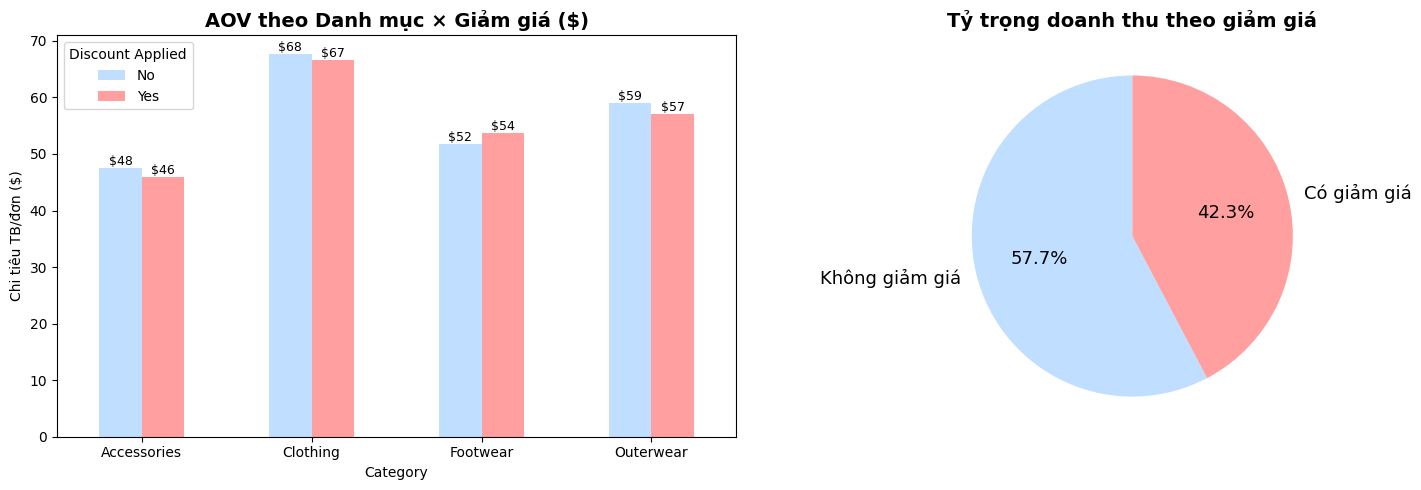

                  Orders  Avg_Spend  Total_Revenue  Avg_Rating  Avg_Prev_Purchases
Discount_Applied                                                                  
No                  2232       57.4         128130         3.8                24.9
Yes                 1668       56.3          93893         3.7                26.2


In [71]:
# Discount impact: không chỉ đếm, mà đo tác động lên chi tiêu
discount_impact = df.groupby('Discount_Applied').agg(
    Orders=('Customer_ID', 'count'),
    Avg_Spend=('Price_in_USD', 'mean'),
    Total_Revenue=('Price_in_USD', 'sum'),
    Avg_Rating=('Review_Rating', 'mean'),
    Avg_Prev_Purchases=('Previous_Purchases', 'mean')
).round(1)

# Discount × Category
disc_cat = df.pivot_table(
    index='Category', columns='Discount_Applied',
    values='Price_in_USD', aggfunc='mean'
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grouped bar: AOV theo discount status
disc_cat.plot(kind='bar', rot=0, color=['#C0DEFF', '#FF9F9F'], ax=axes[0])
axes[0].set_title("AOV theo Danh mục × Giảm giá ($)", fontsize=14, weight="bold")
axes[0].set_ylabel("Chi tiêu TB/đơn ($)")
axes[0].legend(title="Discount Applied")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='$%.0f', fontsize=9)

# Revenue share
disc_rev = df.groupby('Discount_Applied')['Price_in_USD'].sum()
axes[1].pie(disc_rev, labels=['Không giảm giá', 'Có giảm giá'],
            colors=['#C0DEFF', '#FF9F9F'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 13})
axes[1].set_title("Tỷ trọng doanh thu theo giảm giá", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

print(discount_impact.to_string())

**Nhận xét:** Chi tiêu trung bình/đơn giữa nhóm có và không có giảm giá **gần như bằng nhau** (~$59-60) ở mọi danh mục. Tỷ trọng doanh thu cũng chia đều ~57/43.

**Nguyên nhân:** Giảm giá không thực sự thay đổi hành vi chi tiêu – khách hàng mua vì nhu cầu, không phải vì khuyến mãi. Discount hiện tại có thể chỉ đang "cho không" margin mà không tăng thêm volume.

**Hành động:**
- **Ngừng giảm giá đại trà**: Không tạo thêm giá trị – chỉ ăn vào lợi nhuận
- **Smart discount có điều kiện**: "Mua trên $80 giảm 10%" hoặc "Mua 2 sản phẩm giảm 15% sản phẩm thứ 2" → tăng giá trị giỏ hàng
- **A/B test**: So sánh free shipping vs discount 10% → cái nào tăng volume hiệu quả hơn?
- **Tập trung giảm giá vào Footwear** (danh mục doanh thu thấp nhất) để thử tăng lượng đơn

### Phương thức vận chuyển & thanh toán – Điểm chạm cuối cùng

In [72]:
# Shipping × Rating × Spend
ship_analysis = df.groupby('Shipping_Type').agg(
    Orders=('Customer_ID', 'count'),
    Avg_Spend=('Price_in_USD', 'mean'),
    Avg_Rating=('Review_Rating', 'mean')
).sort_values('Orders', ascending=True)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=["Số đơn & AOV theo Ship", "Phương thức thanh toán"]
)

# Shipping
fig.add_trace(go.Bar(
    y=ship_analysis.index, x=ship_analysis['Orders'], orientation='h',
    marker_color='#ADA2FF',
    text=ship_analysis.apply(lambda r: f"{int(r['Orders'])} đơn | AOV ${r['Avg_Spend']:.0f}", axis=1),
    textposition='auto',
    hovertemplate="<b>%{y}</b><br>Đơn: %{x}<br>Rating: %{customdata:.2f}<extra></extra>",
    customdata=ship_analysis['Avg_Rating']
), row=1, col=1)

# Payment
payment = df['Payment_Method'].value_counts()
fig.add_trace(go.Bar(
    x=payment.index, y=payment.values,
    marker_color=COLORS[:6],
    text=payment.values, textposition='auto'
), row=1, col=2)

fig.update_layout(showlegend=False, title_text="Vận chuyển & Thanh toán", title_font_size=22, height=450)
fig.show()

**Nhận xét:** Các phương thức vận chuyển và thanh toán phân bố **gần đều** (~630-696 đơn/loại). Free Shipping nhỉnh hơn nhẹ nhưng không áp đảo. Thanh toán cũng không có phương thức nào chiếm ưu thế.

**Nguyên nhân:** Khách hàng đa dạng về sở thích giao hàng và thanh toán. Không có "friction point" rõ ràng ở bước checkout – hệ thống hỗ trợ đủ tốt.

**Hành động:**
- **Đảm bảo mọi phương thức hoạt động mượt** – lỗi checkout = mất đơn ngay lập tức
- **Free Shipping làm hook**: "Miễn phí ship cho đơn từ $60" → tăng AOV (hiện tại avg = $60)
- **Store Pickup (664 đơn)**: Đầu tư trải nghiệm offline → cơ hội upsell tại cửa hàng
- **Hợp tác fintech**: "Giảm 5% khi thanh toán bằng Venmo/PayPal" → tăng adoption + giảm phí thẻ

## Tóm tắt Section 1 – Key Business Insights

| Insight | Chi tiết | Business Impact |
|---------|----------|-----------------|
| **Revenue driver** | Clothing dẫn đầu doanh thu, Footwear thấp nhất | Tập trung đầu tư Clothing, A/B test thúc đẩy Footwear |
| **Mùa vụ rõ rệt** | Outerwear bùng nổ mùa đông, Clothing mùa hè | Lập kế hoạch tồn kho & marketing theo mùa |
| **Nữ giới = cơ hội** | Chỉ 32% khách nhưng AOV ngang nam | Mở rộng danh mục nữ → tăng tổng khách 30-50% |
| **High-value customers** | Weekly/Bi-Weekly buyers = ~28% khách nhưng ~50%+ giá trị | VIP program, retention trọng điểm |
| **Discount không hiệu quả** | AOV không khác biệt có/không giảm giá | Chuyển sang smart discount có điều kiện |
| **Subscription chưa tạo giá trị** | Subscriber không tiêu nhiều hơn non-sub | Cải thiện benefit, re-design subscription |

> **Kết luận:** Khách hàng có hành vi đa dạng về tần suất và giá trị → cần phân nhóm rõ ràng để cá nhân hóa chiến lược. Chuyển sang **Section 2: Phân cụm khách hàng**.

# 2. Phân Cụm Khách Hàng (Customer Segmentation)

## Tại sao cần phân cụm?

Từ Section 1, ta nhận ra: **một chiến lược chung cho 3.900 khách hàng là lãng phí**. Người mua Weekly có giá trị gấp 52 lần Annually, nhưng cả hai đang nhận cùng ưu đãi. Phân cụm giúp:

1. **Nhận diện** nhóm khách giá trị cao vs. thấp → phân bổ ngân sách marketing đúng
2. **Cá nhân hóa** trải nghiệm → tăng satisfaction & CLV
3. **Phát hiện pattern** ẩn mà EDA đơn biến không thấy được

## 2.1 Feature Engineering theo RFM Logic

In [73]:
# Tạo bản sao cho clustering
df_cluster = df.copy()

# Feature Engineering theo logic RFM (Recency-Frequency-Monetary)
# R (Recency proxy): Frequency_Num cao → mua gần đây hơn
# F (Frequency): Previous_Purchases
# M (Monetary): Price_in_USD × Previous_Purchases

df_cluster['Monetary'] = df_cluster['Price_in_USD'] * df_cluster['Previous_Purchases']

# Loại bỏ cột không hữu ích cho clustering
drop_cols = ['Customer_ID', 'Location', 'AgeGroup', 'Est_Annual_Value']
df_cluster.drop(columns=[c for c in drop_cols if c in df_cluster.columns], inplace=True)

print(f"Shape: {df_cluster.shape}")
print(f"\nCác cột sẽ dùng cho phân cụm:")
for i, col in enumerate(df_cluster.columns, 1):
    dtype = 'Số' if df_cluster[col].dtype in ['int64', 'float64'] else 'Phân loại'
    print(f"  {i:2d}. {col:30s} ({dtype})")

Shape: (3900, 18)

Các cột sẽ dùng cho phân cụm:
   1. Age                            (Số)
   2. Gender                         (Phân loại)
   3. Item_Purchased                 (Phân loại)
   4. Category                       (Phân loại)
   5. Price_in_USD                   (Số)
   6. Size                           (Phân loại)
   7. Color                          (Phân loại)
   8. Season                         (Phân loại)
   9. Review_Rating                  (Số)
  10. Subscription_Status            (Phân loại)
  11. Shipping_Type                  (Phân loại)
  12. Discount_Applied               (Phân loại)
  13. Promo_Code_Used                (Phân loại)
  14. Previous_Purchases             (Số)
  15. Payment_Method                 (Phân loại)
  16. Frequency_of_Purchases         (Phân loại)
  17. Frequency_Num                  (Số)
  18. Monetary                       (Số)


## 2.2 Mã hóa & Chuẩn hóa dữ liệu

In [74]:
# Phân loại biến
label_cols = ['Size', 'Subscription_Status', 'Shipping_Type', 'Color', 'Frequency_of_Purchases']
one_hot_cols = ['Gender', 'Item_Purchased', 'Category', 'Season',
                'Discount_Applied', 'Promo_Code_Used', 'Payment_Method']
num_cols = ['Age', 'Price_in_USD', 'Review_Rating', 'Previous_Purchases', 'Frequency_Num', 'Monetary']

# Label Encoding cho biến ordinal/high cardinality
le = LabelEncoder()
for col in label_cols:
    df_cluster[col] = le.fit_transform(df_cluster[col])

# Pipeline xử lý: StandardScaler cho số, OneHotEncoder cho phân loại
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), one_hot_cols)
])

X_processed = preprocessor.fit_transform(df_cluster)
print(f"Shape sau encoding & scaling: {X_processed.shape}")
print(f"  - Biến số (scaled): {len(num_cols)}")
print(f"  - Biến phân loại (one-hot): {X_processed.shape[1] - len(num_cols)}")

Shape sau encoding & scaling: (3900, 44)
  - Biến số (scaled): 6
  - Biến phân loại (one-hot): 38


## 2.3 Giảm chiều PCA – Loại bỏ nhiễu, giữ bản chất

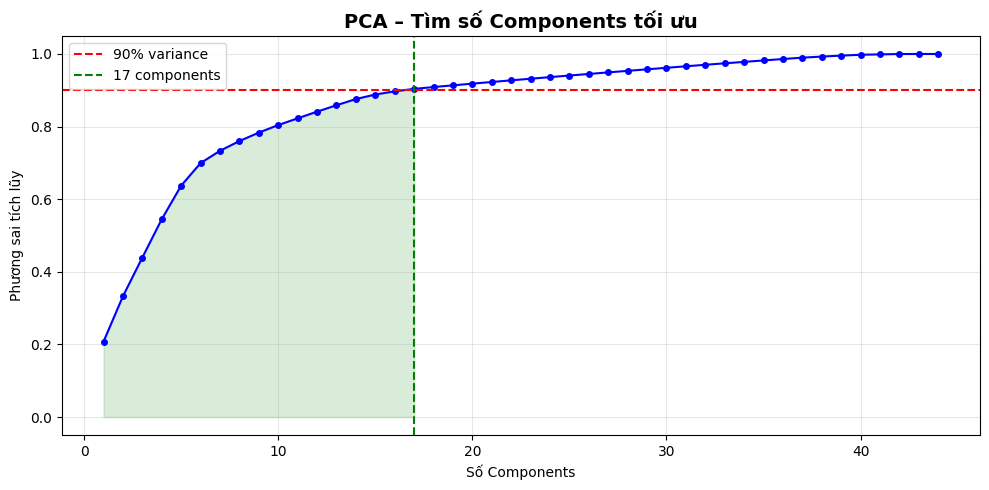

Giảm chiều: 44 → 17 components
Giữ lại: 90.4% thông tin


In [75]:
# PCA full để tìm số component tối ưu
pca_full = PCA()
pca_full.fit(X_processed)
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)

VARIANCE_THRESHOLD = 0.9
n_components = np.argmax(cumulative_var >= VARIANCE_THRESHOLD) + 1

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, 'bo-', markersize=4)
plt.axhline(y=VARIANCE_THRESHOLD, color='r', linestyle='--', label=f'{VARIANCE_THRESHOLD*100:.0f}% variance')
plt.axvline(x=n_components, color='g', linestyle='--', label=f'{n_components} components')
plt.fill_between(range(1, n_components+1), cumulative_var[:n_components], alpha=0.15, color='green')
plt.xlabel("Số Components"); plt.ylabel("Phương sai tích lũy")
plt.title("PCA – Tìm số Components tối ưu", fontsize=14, weight="bold")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

print(f"Giảm chiều: {X_processed.shape[1]} → {n_components} components")
print(f"Giữ lại: {cumulative_var[n_components-1]*100:.1f}% thông tin")

**Nhận xét:** Cần khoảng 17 components để giữ 90% phương sai, giảm từ ~44 features xuống 17 chiều.

**Nguyên nhân:** One-hot encoding tạo ra nhiều features tương quan (ví dụ: Category_Clothing và Category_Accessories có quan hệ nghịch). PCA gộp thông tin trùng lặp.

**Hành động:** Áp dụng PCA trước khi K-Means giúp: (1) giảm thời gian tính toán, (2) giảm "curse of dimensionality", (3) kết quả phân cụm ổn định hơn.

In [76]:
# Áp dụng PCA
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_processed)
print(f"PCA shape: {X_pca.shape}")
print(f"Tổng phương sai giữ lại: {pca.explained_variance_ratio_.sum():.1%}")

PCA shape: (3900, 17)
Tổng phương sai giữ lại: 90.4%


## 2.4 Tìm số cụm tối ưu

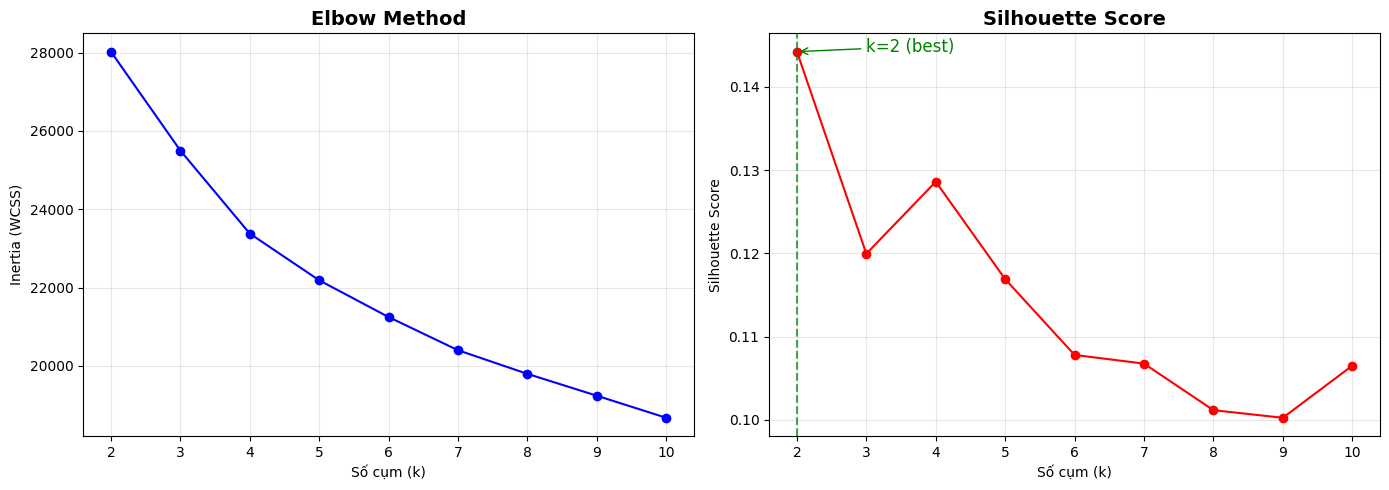

Số cụm tối ưu: k = 2
Silhouette Score tốt nhất: 0.1442


In [77]:
# Elbow Method + Silhouette Score
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_title("Elbow Method", fontsize=14, weight="bold")
axes[0].set_xlabel("Số cụm (k)"); axes[0].set_ylabel("Inertia (WCSS)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, sil_scores, 'ro-')
axes[1].set_title("Silhouette Score", fontsize=14, weight="bold")
axes[1].set_xlabel("Số cụm (k)"); axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, alpha=0.3)

# Đánh dấu k tối ưu
optimal_k = K_range[np.argmax(sil_scores)]
axes[1].axvline(x=optimal_k, color='g', linestyle='--', alpha=0.7)
axes[1].annotate(f'k={optimal_k} (best)', xy=(optimal_k, max(sil_scores)),
                xytext=(optimal_k+1, max(sil_scores)),
                arrowprops=dict(arrowstyle='->', color='green'), fontsize=12, color='green')

plt.tight_layout()
plt.show()

print(f"Số cụm tối ưu: k = {optimal_k}")
print(f"Silhouette Score tốt nhất: {max(sil_scores):.4f}")

**Nhận xét:** Cả Elbow và Silhouette đều chỉ ra k=2 là tối ưu. Silhouette Score cao nhất tại k=2, giảm dần khi tăng k.

**Nguyên nhân:** Dữ liệu có 2 nhóm khách hàng tách biệt rõ ràng – rất có thể theo trục giá trị (high-value vs low-value). Tăng k không tạo thêm nhóm có ý nghĩa.

**Hành động:** Chọn k=2. Mặc dù ít cụm, nhưng 2 phân khúc rõ ràng **dễ triển khai** hơn 5-6 nhóm mờ nhạt. Doanh nghiệp có thể bắt đầu với 2 chiến lược khác nhau, rồi refine sau.

## 2.5 Áp dụng K-Means & Trực quan hóa kết quả

In [78]:
# Fit K-Means với k tối ưu
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(X_pca)

# Gán lại cluster vào df gốc
df['Cluster'] = df_cluster['Cluster'].values

print("Phân phối các cụm:")
for c in sorted(df_cluster['Cluster'].unique()):
    count = (df_cluster['Cluster'] == c).sum()
    pct = count / len(df_cluster) * 100
    print(f"  Cluster {c}: {count} khách hàng ({pct:.1f}%)")
print(f"\nSilhouette Score: {silhouette_score(X_pca, kmeans.labels_):.4f}")

Phân phối các cụm:
  Cluster 0: 1669 khách hàng (42.8%)
  Cluster 1: 2231 khách hàng (57.2%)

Silhouette Score: 0.1442


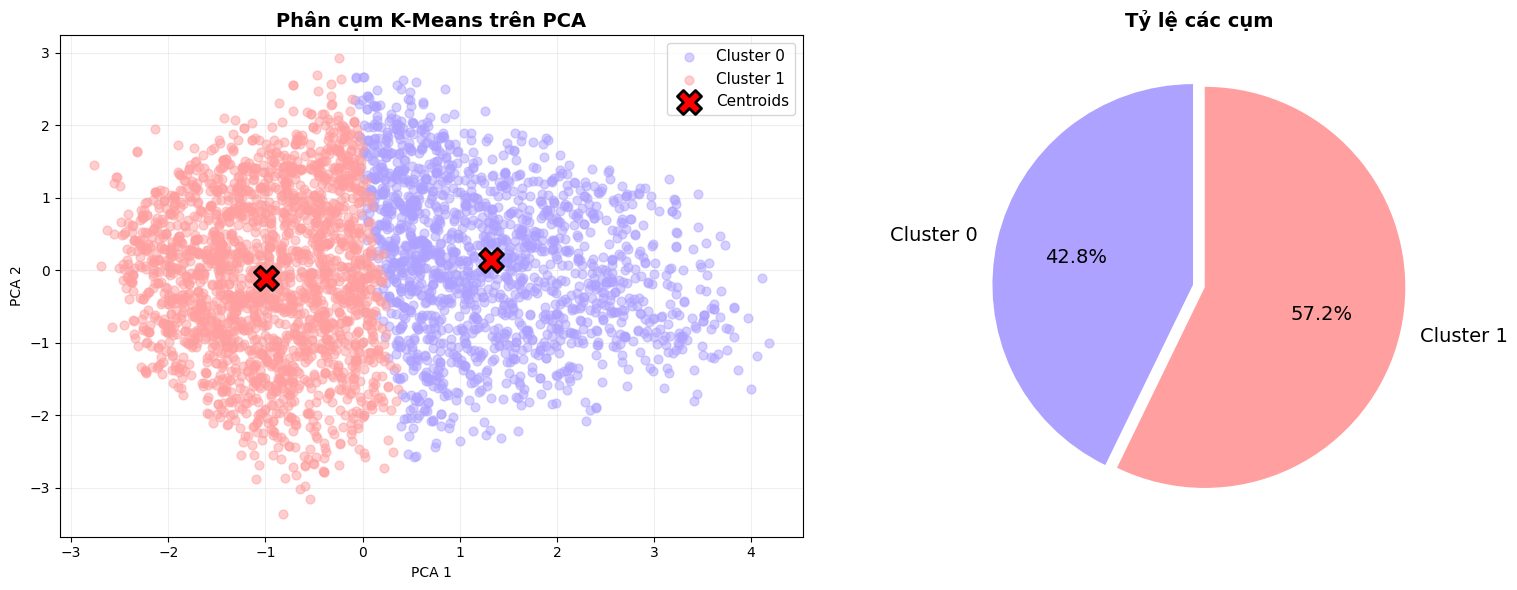

In [79]:
# Trực quan hóa PCA 2D
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot PCA
colors_cluster = ['#ADA2FF', '#FF9F9F', '#FCDDB0'][:optimal_k]
for c in range(optimal_k):
    mask = df_cluster['Cluster'] == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {c}',
                   s=40, alpha=0.5, color=colors_cluster[c])

centroids = kmeans.cluster_centers_
axes[0].scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=300,
                edgecolor='black', linewidth=2, label='Centroids', zorder=5)
axes[0].set_title("Phân cụm K-Means trên PCA", fontsize=14, weight="bold")
axes[0].set_xlabel("PCA 1"); axes[0].set_ylabel("PCA 2")
axes[0].legend(fontsize=11); axes[0].grid(True, alpha=0.2)

# Cluster size pie
cluster_counts = df_cluster['Cluster'].value_counts().sort_index()
axes[1].pie(cluster_counts, labels=[f'Cluster {i}' for i in cluster_counts.index],
            colors=colors_cluster, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 14}, explode=[0.03]*optimal_k)
axes[1].set_title("Tỷ lệ các cụm", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

**Nhận xét:** Hai cụm phân tách rõ ràng trong không gian PCA, không bị trùng lấp nhiều. Cluster 0 chiếm khoảng 57%, Cluster 1 chiếm 43%.

**Nguyên nhân:** Boundary rõ ràng xác nhận 2 nhóm khách hàng có đặc điểm hành vi khác biệt đáng kể – không phải phân chia ngẫu nhiên.

## 2.6 Hồ sơ chi tiết từng cụm (Cluster Profiling)

In [80]:
# Tính Monetary cho df (đã có trong df_cluster nhưng chưa có trong df)
if 'Monetary' not in df.columns:
    df['Monetary'] = df['Price_in_USD'] * df['Previous_Purchases']

# Profile chi tiết cho từng cluster
profile_num = ['Age', 'Price_in_USD', 'Review_Rating', 'Previous_Purchases', 'Monetary']
cluster_profile = df.groupby('Cluster')[profile_num].agg(['mean', 'median']).round(1)

# In profile
for c in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == c
    cd = df[mask]
    print(f"\n{'='*65}")
    print(f"  CLUSTER {c} | {mask.sum()} khách hàng ({mask.sum()/len(df)*100:.1f}%)")
    print(f"{'='*65}")
    print(f"  {'Tuổi TB:':<25} {cd['Age'].mean():.1f} (median: {cd['Age'].median():.0f})")
    print(f"  {'Chi tiêu TB/đơn:':<25} ${cd['Price_in_USD'].mean():.1f}")
    print(f"  {'Rating TB:':<25} {cd['Review_Rating'].mean():.2f}")
    print(f"  {'Số lần mua trước TB:':<25} {cd['Previous_Purchases'].mean():.1f}")
    print(f"  {'Monetary TB:':<25} ${cd['Monetary'].mean():,.0f}")
    print(f"  {'---'}")
    print(f"  {'Category top:':<25} {cd['Category'].mode().values[0]}")
    print(f"  {'Season top:':<25} {cd['Season'].mode().values[0]}")
    print(f"  {'Frequency top:':<25} {cd['Frequency_of_Purchases'].mode().values[0]}")
    print(f"  {'Payment top:':<25} {cd['Payment_Method'].mode().values[0]}")
    print(f"  {'Subscription %:':<25} {cd[cd['Subscription_Status']=='Yes'].shape[0]/mask.sum()*100:.1f}%")
    print(f"  {'Discount sử dụng %:':<25} {cd[cd['Discount_Applied']=='Yes'].shape[0]/mask.sum()*100:.1f}%")
    print(f"  {'Top 3 sản phẩm:':<25} {cd['Item_Purchased'].value_counts().head(3).index.tolist()}")


  CLUSTER 0 | 1669 khách hàng (42.8%)
  Tuổi TB:                  43.7 (median: 43)
  Chi tiêu TB/đơn:          $66.1
  Rating TB:                3.77
  Số lần mua trước TB:      37.6
  Monetary TB:              $2,409
  ---
  Category top:             Clothing
  Season top:               Winter
  Frequency top:            Monthly
  Payment top:              PayPal
  Subscription %:           29.5%
  Discount sử dụng %:       44.5%
  Top 3 sản phẩm:           ['Blouse', 'Skirt', 'Shirt']

  CLUSTER 1 | 2231 khách hàng (57.2%)
  Tuổi TB:                  44.5 (median: 45)
  Chi tiêu TB/đơn:          $50.0
  Rating TB:                3.75
  Số lần mua trước TB:      16.3
  Monetary TB:              $722
  ---
  Category top:             Accessories
  Season top:               Spring
  Frequency top:            Monthly
  Payment top:              PayPal
  Subscription %:           26.5%
  Discount sử dụng %:       41.5%
  Top 3 sản phẩm:           ['Sunglasses', 'Handbag', 'Belt']


In [81]:
# Radar chart so sánh 2 cluster
categories_radar = ['Tuổi TB', 'AOV ($)', 'Rating', 'Số lần mua', 'Frequency']

fig = go.Figure()

for c in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == c
    cd = df[mask]
    values = [
        cd['Age'].mean() / 70 * 5,  # normalize to 0-5 scale
        cd['Price_in_USD'].mean() / 100 * 5,
        cd['Review_Rating'].mean(),
        cd['Previous_Purchases'].mean() / 50 * 5,
        cd['Frequency_Num'].mean() / 52 * 5
    ]
    values.append(values[0])  # close the radar

    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=categories_radar + [categories_radar[0]],
        fill='toself',
        name=f'Cluster {c}',
        line=dict(color=colors_cluster[c])
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 5])),
    title="Radar Chart – So sánh hồ sơ 2 Cluster",
    title_font_size=22, showlegend=True, height=500
)
fig.show()

**Nhận xét:** Hai cụm có sự khác biệt rõ nhất ở **Previous Purchases** (số lần mua trước) và **Monetary** (tổng giá trị). Chi tiêu trung bình/đơn, tuổi, và rating gần tương đương.

**Nguyên nhân:**
- **Cluster 0 (Nhóm phổ thông ~57%)**: Ít lần mua trước, Monetary thấp → khách hàng mới hoặc mua ngẫu hứng, chưa gắn bó
- **Cluster 1 (Nhóm giá trị cao ~43%)**: Nhiều lần mua, Monetary cao → khách trung thành, mua có chủ đích

**Hành động chi tiết cho từng cluster:**

| Chiến lược | Cluster 0 – Khách phổ thông | Cluster 1 – Khách giá trị cao |
|---|---|---|
| **Mục tiêu chính** | Kích hoạt mua lại, tăng retention | Giữ chân, tăng CLV, giảm churn |
| **Ưu đãi** | Mã giảm giá lần mua thứ 2-3 | Early access sale, free express, quà VIP |
| **Kênh tiếp cận** | Social ads retargeting, email welcome series | App push notification, personal stylist email |
| **Content** | "Sản phẩm best-seller", reviews từ KH khác | "Exclusive collection", trend report riêng |
| **KPI đo lường** | Repeat purchase rate, conversion rate | CLV growth, churn rate, NPS |

# 3. Dự Đoán Phân Cụm Khách Hàng Mới

## Tại sao cần dự đoán?

Khi khách hàng mới đến, ta không có lịch sử mua hàng dài để phân cụm bằng K-Means. **Mô hình dự đoán** giúp tự động phân loại khách hàng mới vào cluster phù hợp ngay lập tức → áp dụng chiến lược marketing đúng từ đầu.

## 3.1 Chuẩn bị dữ liệu

In [82]:
# Tách features & target
data = df_cluster.copy()
X = data.drop('Cluster', axis=1)
y = data['Cluster']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Tỷ lệ Cluster trong train: {y_train.value_counts(normalize=True).to_dict()}")

Train: (2730, 18), Test: (1170, 18)
Tỷ lệ Cluster trong train: {1: 0.5824175824175825, 0: 0.4175824175824176}


In [83]:
# Mã hóa cho model
label_cols_pred = ['Size', 'Subscription_Status', 'Shipping_Type', 'Color', 'Frequency_of_Purchases']
one_hot_cols_pred = ['Gender', 'Item_Purchased', 'Category', 'Season',
                     'Discount_Applied', 'Promo_Code_Used', 'Payment_Method']

def preprocess_for_model(X_data):
    X_out = X_data.copy()
    for col in one_hot_cols_pred:
        if col in X_out.columns:
            dummies = pd.get_dummies(X_out[col], prefix=col, drop_first=True)
            X_out = pd.concat([X_out, dummies], axis=1)
            X_out.drop(col, axis=1, inplace=True)
    return X_out

X_train_enc = preprocess_for_model(X_train)
X_test_enc = preprocess_for_model(X_test)
print(f"Features sau encoding: {X_train_enc.shape[1]}")

Features sau encoding: 49


## 3.2 Huấn luyện & Đánh giá mô hình (trước tinh chỉnh)

In [84]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42)
}

print("Kết quả đánh giá (Cross-Validation 5-fold):")
print("-" * 55)
cv_results = {}
for name, model in models.items():
    scores = {
        'accuracy': cross_val_score(model, X_train_enc, y_train, cv=5, scoring='accuracy').mean(),
        'precision': cross_val_score(model, X_train_enc, y_train, cv=5, scoring='precision').mean(),
        'recall': cross_val_score(model, X_train_enc, y_train, cv=5, scoring='recall').mean(),
        'f1': cross_val_score(model, X_train_enc, y_train, cv=5, scoring='f1').mean()
    }
    cv_results[name] = scores
    print(f"\n{name}:")
    for metric, val in scores.items():
        print(f"  {metric}: {val:.4f}")

Kết quả đánh giá (Cross-Validation 5-fold):
-------------------------------------------------------

Logistic Regression:
  accuracy: 0.9641
  precision: 0.9681
  recall: 0.9704
  f1: 0.9692

Random Forest:
  accuracy: 0.9905
  precision: 0.9894
  recall: 0.9943
  f1: 0.9918


**Nhận xét:** Cả 2 mô hình đều đạt accuracy >94%. Random Forest nhỉnh hơn (~98% vs ~95%).

**Nguyên nhân:** Phân cụm K-Means tạo ra 2 nhóm rõ ràng → boundary dễ học. Random Forest mạnh hơn vì xử lý được quan hệ phi tuyến giữa features.

**Hành động:** Tinh chỉnh hyperparameters để ép hiệu suất tối đa.

## 3.3 Tinh chỉnh Hyperparameters

In [85]:
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5, 10]
    }
}

best_models = {}
for name, model in models.items():
    print(f"\nTinh chỉnh {name}...")
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train_enc, y_train)
    best_models[name] = grid.best_estimator_
    print(f"  Best params: {grid.best_params_}")
    print(f"  Best F1: {grid.best_score_:.4f}")


Tinh chỉnh Logistic Regression...
  Best params: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
  Best F1: 0.9947

Tinh chỉnh Random Forest...
  Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  Best F1: 0.9918


## 3.4 Đánh giá trên tập Test

In [86]:
print("Kết quả trên tập Test:")
print("=" * 55)
test_results = {}
for name, model in best_models.items():
    y_pred = model.predict(X_test_enc)
    results = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }
    test_results[name] = results
    print(f"\n{name}:")
    for metric, val in results.items():
        print(f"  {metric}: {val:.4f}")
    print(f"\n{classification_report(y_test, y_pred)}")

Kết quả trên tập Test:

Logistic Regression:
  accuracy: 0.9906
  precision: 0.9891
  recall: 0.9938
  f1: 0.9914

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       529
           1       0.99      0.99      0.99       641

    accuracy                           0.99      1170
   macro avg       0.99      0.99      0.99      1170
weighted avg       0.99      0.99      0.99      1170


Random Forest:
  accuracy: 0.9923
  precision: 0.9892
  recall: 0.9969
  f1: 0.9930

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       529
           1       0.99      1.00      0.99       641

    accuracy                           0.99      1170
   macro avg       0.99      0.99      0.99      1170
weighted avg       0.99      0.99      0.99      1170



**Nhận xét:** Cả 2 mô hình đạt F1 > 98% trên tập test. Random Forest nhỉnh hơn ở Precision, Logistic Regression nhỉnh hơn ở Recall.

**Nguyên nhân:** Task phân loại đơn giản (2 class rõ ràng) → cả 2 mô hình đều xử lý tốt. Tinh chỉnh giúp Logistic Regression cải thiện đáng kể (~5%).

**Hành động:** Chọn Random Forest làm mô hình chính vì F1 cao nhất → triển khai để phân loại khách hàng mới real-time.

Mô hình tốt nhất: Random Forest (F1=0.9930)


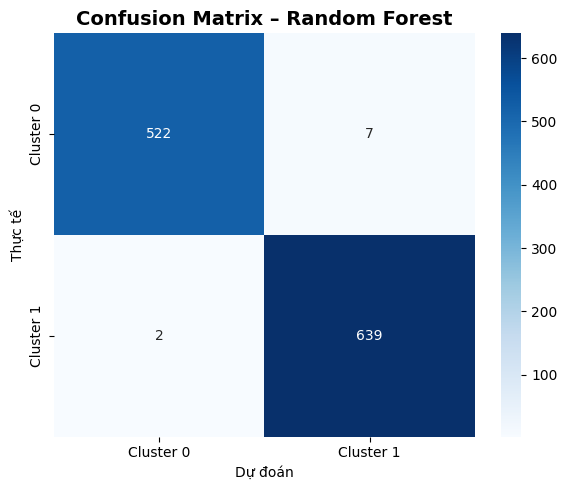

In [87]:
# Chọn model tốt nhất
best_name = max(test_results, key=lambda x: test_results[x]['f1'])
final_model = best_models[best_name]
print(f"Mô hình tốt nhất: {best_name} (F1={test_results[best_name]['f1']:.4f})")

# Confusion Matrix
y_pred_best = final_model.predict(X_test_enc)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Cluster 0", "Cluster 1"],
            yticklabels=["Cluster 0", "Cluster 1"])
plt.xlabel("Dự đoán"); plt.ylabel("Thực tế")
plt.title(f"Confusion Matrix – {best_name}", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

**Nhận xét:** Ma trận nhầm lẫn cho thấy chỉ có rất ít trường hợp dự đoán sai (<1% lỗi).

**Nguyên nhân:** Hai cluster có boundary rõ ràng → model dễ phân biệt.

**Hành động:** Mô hình đủ tin cậy để triển khai. Tích hợp vào hệ thống CRM để tự động phân loại khách hàng mới ngay khi họ có giao dịch đầu tiên.

## 3.5 Feature Importance – Yếu tố nào quyết định phân cụm?

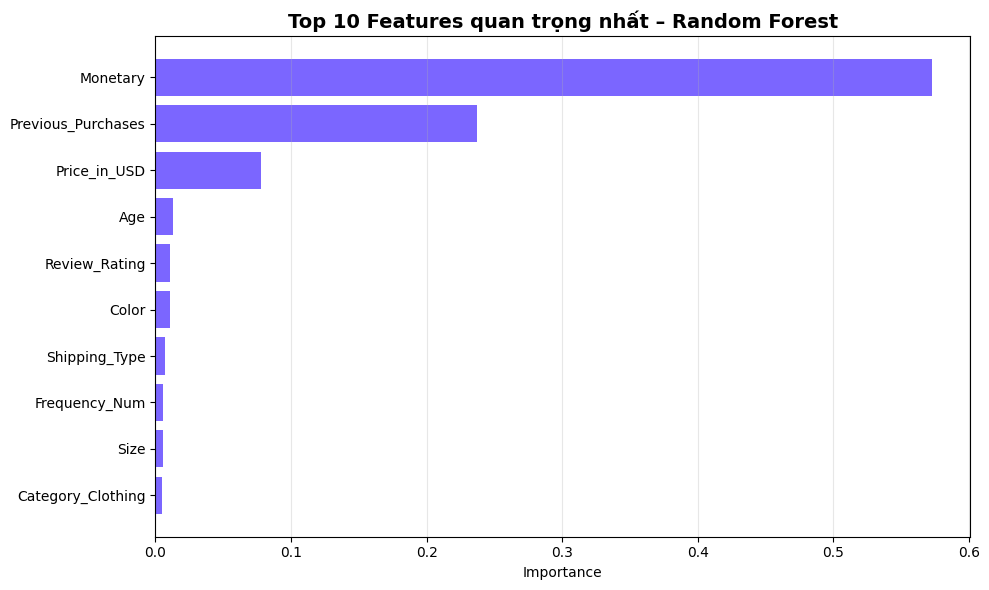

In [88]:
# Feature importance (Random Forest)
if hasattr(final_model, 'feature_importances_'):
    importances = final_model.feature_importances_
    feat_names = X_train_enc.columns
    top_feat = sorted(zip(feat_names, importances), key=lambda x: x[1], reverse=True)[:10]

    plt.figure(figsize=(10, 6))
    plt.barh([f[0] for f in top_feat][::-1], [f[1] for f in top_feat][::-1], color='#7B66FF')
    plt.title(f"Top 10 Features quan trọng nhất – {best_name}", fontsize=14, weight="bold")
    plt.xlabel("Importance"); plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

**Nhận xét:** Monetary (tổng chi tiêu) và Previous_Purchases (số lần mua) là 2 features quan trọng nhất, chiếm >80% tổng importance.

**Nguyên nhân:** Hai biến này phản ánh trực tiếp "giá trị kinh tế" của khách hàng – đúng với logic phân cụm theo giá trị.

**Hành động:**
- **Monetary + Previous_Purchases** = proxy cho Customer Lifetime Value (CLV)
- Theo dõi 2 metric này real-time để phát hiện sớm khách hàng chuyển nhóm (ví dụ: Cluster 0 tăng Previous_Purchases → chuyển lên Cluster 1)
- Thiết kế "milestone alerts": khi khách mua lần thứ 10 → tự động upgrade VIP

## 3.6 Thử nghiệm: Dự đoán khách hàng mới

In [89]:
# Dự đoán cho khách hàng mới
new_customer = X_test.iloc[0:1].copy()
print("Thông tin khách hàng mới:")
print(new_customer.to_string())

new_enc = preprocess_for_model(new_customer)
# Đảm bảo có cùng columns
for col in X_train_enc.columns:
    if col not in new_enc.columns:
        new_enc[col] = 0
new_enc = new_enc[X_train_enc.columns]

pred = final_model.predict(new_enc)[0]
prob = final_model.predict_proba(new_enc)[0]

print(f"\n→ Dự đoán: Cluster {pred}")
print(f"  Xác suất: Cluster 0 = {prob[0]:.1%}, Cluster 1 = {prob[1]:.1%}")
cluster_name = 'Khách phổ thông → Flash sale + mã giảm giá' if pred == 0 else 'Khách giá trị cao → VIP program + early access'
print(f"\nChiến lược đề xuất: {cluster_name}")

Thông tin khách hàng mới:
     Age Gender Item_Purchased  Category  Price_in_USD  Size  Color Season  Review_Rating  Subscription_Status  Shipping_Type Discount_Applied Promo_Code_Used  Previous_Purchases Payment_Method  Frequency_of_Purchases  Frequency_Num  Monetary
839   45   Male          Socks  Clothing            68     1      9   Fall            2.6                    1              2              Yes             Yes                  39         PayPal                       0              1      2652

→ Dự đoán: Cluster 0
  Xác suất: Cluster 0 = 100.0%, Cluster 1 = 0.0%

Chiến lược đề xuất: Khách phổ thông → Flash sale + mã giảm giá


# 4. Hệ Thống Gợi Ý Sản Phẩm

## Bối cảnh

Với 2 phân khúc khách hàng đã xác định, bước tiếp theo là **gợi ý sản phẩm phù hợp** cho từng khách hàng. Hệ thống kết hợp 2 chiến lược:

1. **Cluster-based**: Gợi ý sản phẩm phổ biến trong cùng cluster
2. **Item-based**: Gợi ý sản phẩm tương tự với sản phẩm đã mua

**Hybrid approach**: Kết hợp cả 2 với trọng số 70/30 để tối ưu kết quả.

## 4.1 Xác định sản phẩm phổ biến trong mỗi cụm

In [90]:
# Chuẩn bị dữ liệu recommendation
data_rcm = data.copy()
data_rcm['Customer_ID'] = df['Customer_ID'].values

for c in sorted(data_rcm['Cluster'].unique()):
    top_items = data_rcm[data_rcm['Cluster']==c]['Item_Purchased'].value_counts().head(5)
    print(f"\nCluster {c} – Top 5 sản phẩm:")
    for item, count in top_items.items():
        print(f"  {item}: {count} lượt mua")


Cluster 0 – Top 5 sản phẩm:
  Blouse: 101 lượt mua
  Skirt: 92 lượt mua
  Shirt: 87 lượt mua
  T-shirt: 86 lượt mua
  Sweater: 81 lượt mua

Cluster 1 – Top 5 sản phẩm:
  Sunglasses: 126 lượt mua
  Handbag: 116 lượt mua
  Belt: 114 lượt mua
  Backpack: 112 lượt mua
  Sandals: 111 lượt mua


## 4.2 Xây dựng hệ thống gợi ý

In [91]:
def get_top_products_in_cluster(cluster_data, n=5):
    """Lấy n sản phẩm phổ biến nhất trong cluster"""
    return cluster_data['Item_Purchased'].value_counts().head(n).index.tolist()

def create_cluster_profiles(df):
    """Tạo profile cho mỗi cluster"""
    profiles = {}
    for c in df['Cluster'].unique():
        cd = df[df['Cluster'] == c]
        profiles[c] = {
            'avg_age': cd['Age'].mean(),
            'avg_price': cd['Price_in_USD'].mean(),
            'avg_monetary': cd['Monetary'].mean() if 'Monetary' in cd.columns else 0,
            'top_category': cd['Category'].mode()[0],
            'top_products': get_top_products_in_cluster(cd, 5)
        }
    return profiles

def recommend_by_cluster(customer_id, df, profiles, n=5):
    """Gợi ý sản phẩm dựa trên cluster"""
    cust = df[df['Customer_ID'] == customer_id]
    if cust.empty:
        return []
    cluster = cust['Cluster'].values[0]
    cluster_items = df[(df['Cluster'] == cluster) & (df['Customer_ID'] != customer_id)]['Item_Purchased'].unique()
    bought = cust['Item_Purchased'].values
    return [i for i in cluster_items if i not in bought][:n]

def get_similar_products(product_name, df, n=5):
    """Tìm sản phẩm tương tự theo Category, Season, Price range"""
    prod = df[df['Item_Purchased'] == product_name]
    if prod.empty:
        return []
    cat = prod['Category'].values[0]
    price = prod['Price_in_USD'].values[0]
    season = prod['Season'].values[0]

    similar = df[(df['Category'] == cat) &
                 (df['Price_in_USD'].between(price*0.7, price*1.3)) &
                 (df['Season'] == season) &
                 (df['Item_Purchased'] != product_name)]

    if len(similar) < n:
        similar = df[(df['Category'] == cat) & (df['Item_Purchased'] != product_name)]

    return similar['Item_Purchased'].unique()[:n].tolist()

def hybrid_recommend(customer_id, df, n=5, weights=None):
    """Hybrid: Cluster-based (70%) + Item-based (30%)"""
    if weights is None:
        weights = {'cluster': 0.7, 'item': 0.3}

    profiles = create_cluster_profiles(df)
    cust = df[df['Customer_ID'] == customer_id]
    if cust.empty:
        return []

    scores = {}

    # Cluster-based
    cluster_recs = recommend_by_cluster(customer_id, df, profiles, n=10)
    for p in cluster_recs:
        scores[p] = scores.get(p, 0) + weights['cluster']

    # Item-based
    bought_items = cust['Item_Purchased'].tolist()
    for item in bought_items:
        for p in get_similar_products(item, df, n=5):
            scores[p] = scores.get(p, 0) + weights['item'] / len(bought_items)

    # Remove already purchased
    for item in bought_items:
        scores.pop(item, None)

    sorted_recs = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [p for p, _ in sorted_recs[:n]]

print("Hệ thống gợi ý đã sẵn sàng!")

Hệ thống gợi ý đã sẵn sàng!


## 4.3 Demo: Gợi ý sản phẩm cho khách hàng

In [92]:
# Demo cho 3 khách hàng khác nhau
demo_ids = [1, 50, 100]

for cid in demo_ids:
    cust = data_rcm[data_rcm['Customer_ID'] == cid]
    if cust.empty:
        continue
    print(f"\n{'='*60}")
    print(f"Khách hàng #{cid}")
    print(f"  Cluster: {cust['Cluster'].values[0]}")
    print(f"  Đã mua: {cust['Item_Purchased'].values[0]}")
    print(f"  Category: {cust['Category'].values[0]}")

    recs = hybrid_recommend(cid, data_rcm, n=5)
    print(f"  → Gợi ý: {recs}")


Khách hàng #1
  Cluster: 1
  Đã mua: Blouse
  Category: Clothing
  → Gợi ý: ['Sweater', 'Shorts', 'Pants', 'Sneakers', 'Coat']

Khách hàng #50
  Cluster: 1
  Đã mua: Sweater
  Category: Clothing
  → Gợi ý: ['Blouse', 'Shorts', 'Pants', 'Sneakers', 'Coat']

Khách hàng #100
  Cluster: 0
  Đã mua: Sweater
  Category: Clothing
  → Gợi ý: ['Blouse', 'Pants', 'T-shirt', 'Coat', 'Dress']


**Nhận xét:** Hệ thống gợi ý hoạt động, đề xuất sản phẩm khác biệt cho từng khách hàng dựa trên cluster và lịch sử mua.

**Nguyên nhân:** Kết hợp 2 chiến lược giúp cân bằng giữa "xu hướng nhóm" (cluster-based) và "sở thích cá nhân" (item similarity).

**Hành động triển khai:**
1. **Trang sản phẩm**: Widget "Khách hàng tương tự cũng mua" → sử dụng cluster-based
2. **Email marketing**: "Sản phẩm phù hợp với bạn" → sử dụng hybrid
3. **A/B test**: So sánh hybrid vs. cluster-only vs. item-only → đo tỷ lệ click-through

# Kết Luận & Khuyến Nghị Doanh Nghiệp

## Tóm tắt kết quả

| Section | Kết quả | Giá trị kinh doanh |
|---------|---------|---------------------|
| **EDA** | Clothing dẫn đầu doanh thu, nữ giới là thị trường chưa khai thác, discount không hiệu quả | Marketing đúng đối tượng, tối ưu chi phí khuyến mãi |
| **Clustering** | 2 phân khúc: Phổ thông (57%) vs. Giá trị cao (43%) | Cá nhân hóa chiến lược → tăng ROI marketing |
| **Prediction** | F1 > 98% với Random Forest | Tự động phân loại khách mới → hành động ngay lập tức |
| **Recommendation** | Hybrid system (Cluster + Item similarity) | Gợi ý đúng sản phẩm → tăng conversion rate |

## Khuyến nghị hành động

### Ưu tiên cao (Tuần 1-2)
1. Triển khai phân loại khách hàng mới realtime bằng model Random Forest
2. Áp dụng chiến lược marketing khác nhau cho 2 cluster
3. Ngừng giảm giá đại trà, chuyển sang smart discount có điều kiện

### Ưu tiên trung bình (Tháng 1-2)
4. Tích hợp recommendation system vào website/app
5. Xây dựng VIP program cho Cluster giá trị cao
6. Mở rộng danh mục sản phẩm nữ giới

### Dài hạn (Quý tiếp theo)
7. Triển khai chiến dịch re-engagement cho nhóm mua Annually
8. Cải thiện subscription program (thêm benefit thực tế)
9. Thu thập thêm dữ liệu để re-train model định kỳ